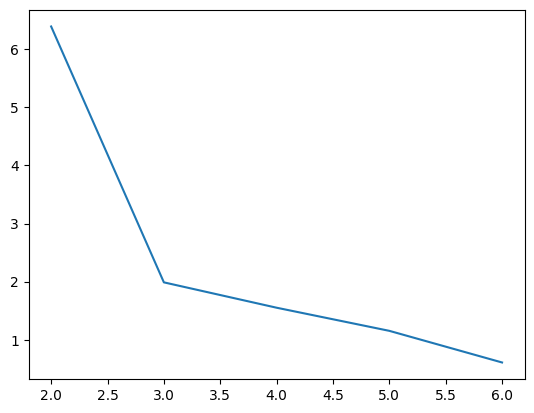

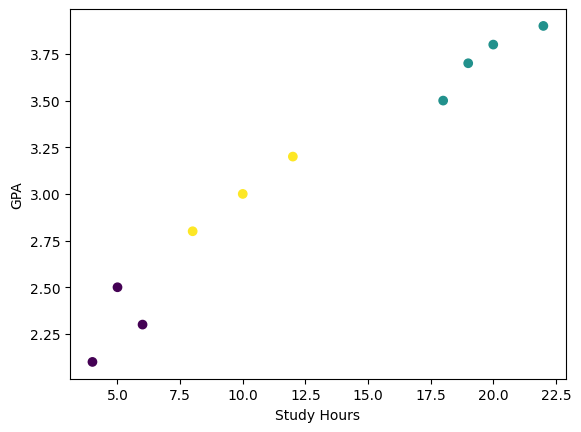

   student_id  cluster
0           1        1
1           2        0
2           3        1
3           4        0
4           5        1
5           6        2
6           7        2
7           8        2
8           9        1
9          10        0


In [31]:
import pandas as pd
import matplotlib.pyplot as mtp
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id': range(1, 11),
    'GPA': [3.8, 2.5, 3.9, 2.1, 3.5, 2.8, 3.2, 3.0, 3.7, 2.3],
    'study_hours': [20, 5, 22, 4, 18, 8, 12, 10, 19, 6],
    'attendance_rate': [95, 70, 98, 60, 90, 75, 85, 80, 92, 65]
}
df = pd.DataFrame(data)
x = df[['GPA', 'study_hours', 'attendance_rate']]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

wcss = []
for i in range(2, 7):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42)
    km.fit(x_scaled)
    wcss.append(km.inertia_)

mtp.plot(range(2, 7), wcss)
mtp.show()

# Based on Elbow, choosing K=3
opt_km = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = opt_km.fit_predict(x_scaled)

mtp.scatter(df['study_hours'], df['GPA'], c=df['cluster'])
mtp.xlabel('Study Hours')
mtp.ylabel('GPA')
mtp.show()

print(df[['student_id', 'cluster']])

In [30]:
!pip install ortools